# Task 3 — Missing labels in training

Compare four training strategies: **Oracle** (true **Y** on every training row), **observed-only** (FISTA Lasso on rows with known **Y** only), **KNN completion** (missing **Y** filled from k-nearest labeled neighbors in standardized **X**, then FISTA on all rows), **mean imputation** (missing **Y** filled with majority class among observed labels, then FISTA on all rows).

Missingness is injected only on the training–fit split; validation and test keep full labels. Test metrics: accuracy, balanced accuracy, F1, ROC AUC.

If you change code under `src/`, re-run the imports cell (it reloads `UnlabeledLogReg`) or use **Kernel → Restart**.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.data_preparation import generate_missing, mcar
from src.metrics.classification import compute_metric
from src.models.logistic_lasso_fista import LogisticLassoFISTA

import importlib
import src.models.unlabeled_logreg as _unlabeled_mod

importlib.reload(_unlabeled_mod)
UnlabeledLogReg = _unlabeled_mod.UnlabeledLogReg

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

In [2]:
RANDOM_STATE = 42
MISSING_FRAC = 0.2
VAL_FRAC = 0.2
TEST_SIZE = 0.2
KNN_K = 5
N_LAMBDAS = 25
VALIDATION_METRIC = "roc_auc"

DATASETS = [
    "bioresponse.csv",
    "gallstones.csv",
    "musk.csv",
    "spectrometer.csv",
]
DATA_DIR = os.path.join(ROOT, "data")

METRICS = ["accuracy", "balanced_accuracy", "f1", "roc_auc"]

METHOD_ORDER = [
    "Oracle",
    "Naive",
    f"Unlabeled_knn_k{KNN_K}",
    "Unlabeled_mean",
]

SCENARIO_KEYS = ["MCAR", "MAR1", "MAR2", "MNAR"]

METHOD_LABELS_SHORT = {
    "Oracle": "Oracle\n(all true Y)",
    "Naive": "Observed\nonly",
    f"Unlabeled_knn_k{KNN_K}": f"KNN\nk={KNN_K}",
    "Unlabeled_mean": "Mean\nimpute",
}
METHOD_LEGEND_LABELS = {
    "Oracle": "Oracle — true Y on all training rows (reference)",
    "Naive": "Observed only — FISTA on rows with known Y",
    f"Unlabeled_knn_k{KNN_K}": f"KNN imputation — missing Y from k={KNN_K} neighbor labels, FISTA on all rows",
    "Unlabeled_mean": "Mean imputation — missing Y → majority class among observed, FISTA on all rows",
}
METHOD_COLORS = {
    "Oracle": "#1a7f37",
    "Naive": "#c45c00",
    f"Unlabeled_knn_k{KNN_K}": "#6a5acd",
    "Unlabeled_mean": "#1f77b4",
}
SCENARIO_DESCRIPTIONS = {
    "MCAR": "MCAR: missing completely at random",
    "MAR1": "MAR1: missingness depends on one X",
    "MAR2": "MAR2: missingness depends on several X",
    "MNAR": "MNAR: missing not at random (X and Y)",
}
METRIC_TITLES = {
    "accuracy": "Accuracy",
    "balanced_accuracy": "Balanced accuracy",
    "f1": "F1 score",
    "roc_auc": "ROC AUC",
}
def _analysis_banner_lines(dataset_name: str) -> tuple[str, str, str]:
    """Standard 3-line context: dataset, mechanisms, missingness rate (for titles + prints)."""
    line1 = f"Dataset: {dataset_name}"
    line2 = (
        "Mechanisms in main grid: MCAR · MAR1 · MAR2 · MNAR  "
        "(MNAR = Missing Not At Random — not “NMAR”)"
    )
    line3 = (
        f"Training–fit missingness target: ≈ {MISSING_FRAC:.0%} of labels removed "
        f"(MCAR uses c = {MISSING_FRAC:.2f}; MAR/MNAR use calibrated logistic masks for this mean rate)"
    )
    return line1, line2, line3


In [3]:
MIN_STRATUM_N = 5


def _standardize_fit_val_test(
    X_sub: np.ndarray,
    y_sub: np.ndarray,
    X_val: np.ndarray,
    X_test: np.ndarray,
) -> tuple[pd.DataFrame, np.ndarray, np.ndarray]:
    """Fit scaler on X_sub; return standardized fit df and scaled val/test feature matrices."""
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X_sub)
    n_features = Xs.shape[1]
    cols = [f"f{i}" for i in range(n_features)]
    df_std = pd.DataFrame(Xs, columns=cols)
    df_std["class"] = y_sub.astype(int)
    X_val_s = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test)
    return df_std, X_val_s, X_test_s


def build_standardized_df(X: np.ndarray, y: np.ndarray) -> pd.DataFrame:
    """Single-split standardization (legacy helper)."""
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    cols = [f"f{i}" for i in range(Xs.shape[1])]
    df = pd.DataFrame(Xs, columns=cols)
    df["class"] = y.astype(int)
    return df


def apply_missingness(
    df_std: pd.DataFrame,
    scenario: str,
    rng: np.random.Generator,
    *,
    target_fraction: float,
    bx: np.ndarray | None = None,
) -> tuple[pd.DataFrame, dict]:
    """Return df with `class_observed` (-1 missing), `class` dropped. meta may contain `bx` for MAR2/MNAR."""
    df = df_std.copy()
    n_features = df.shape[1] - 1
    meta: dict = {}
    if scenario == "MCAR":
        out, _, _ = mcar(df, target_fraction, rng=rng)
        return out, meta
    if scenario == "MAR1":
        out, _, _, _, _ = generate_missing(
            target_fraction, df, None, 0, 0.8, "MAR", 1, rng=rng
        )
        return out, meta
    if scenario == "MAR2":
        if bx is None:
            bx = rng.uniform(0.1, 1.0, n_features)
        meta["bx"] = bx
        out, _, _, _, _ = generate_missing(
            target_fraction, df, bx, None, 0.8, "MAR", 1, rng=rng
        )
        return out, meta
    if scenario == "MNAR":
        if bx is None:
            bx = rng.uniform(0.1, 1.0, n_features)
        meta["bx"] = bx
        out, _, _, _, _ = generate_missing(
            target_fraction, df, bx, None, 0.8, "MNAR", 1.5, rng=rng
        )
        return out, meta
    raise ValueError(scenario)


def simulate_test_unobs_mask(
    df_test_std: pd.DataFrame,
    scenario: str,
    target_fraction: float,
    rng_test: np.random.Generator,
    *,
    bx: np.ndarray | None = None,
) -> np.ndarray | None:
    """True = simulated missing label on test (sim_unobs stratum). MAR/MNAR only; MCAR returns None."""
    if scenario == "MCAR":
        return None
    df = df_test_std.copy()
    if scenario == "MAR1":
        _, _, _, _, mask = generate_missing(
            target_fraction, df, None, 0, 0.8, "MAR", 1, rng=rng_test
        )
        return mask
    if scenario == "MAR2":
        assert bx is not None
        _, _, _, _, mask = generate_missing(
            target_fraction, df, bx, None, 0.8, "MAR", 1, rng=rng_test
        )
        return mask
    if scenario == "MNAR":
        assert bx is not None
        _, _, _, _, mask = generate_missing(
            target_fraction, df, bx, None, 0.8, "MNAR", 1.5, rng=rng_test
        )
        return mask
    raise ValueError(scenario)


def score_test(y_test: np.ndarray, proba: np.ndarray) -> dict[str, float]:
    return {m: float(compute_metric(m, y_test, proba, threshold=0.5).value) for m in METRICS}


def score_test_stratified(
    y_test: np.ndarray,
    proba: np.ndarray,
    scenario: str,
    test_unobs_mask: np.ndarray | None,
) -> dict[str, dict[str, float]]:
    """Keys: `all`; for MAR/MNAR also `sim_obs` and `sim_unobs` (mask True = would be missing)."""
    out: dict[str, dict[str, float]] = {"all": score_test(y_test, proba)}
    if scenario == "MCAR" or test_unobs_mask is None:
        return out
    for key, sel in (("sim_unobs", test_unobs_mask), ("sim_obs", ~test_unobs_mask)):
        if sel.sum() < MIN_STRATUM_N or len(np.unique(y_test[sel])) < 2:
            out[key] = {m: float("nan") for m in METRICS}
        else:
            out[key] = score_test(y_test[sel], proba[sel])
    return out


def _nan_strata(scenario: str, test_unobs_mask: np.ndarray | None) -> dict[str, dict[str, float]]:
    nan = {m: float("nan") for m in METRICS}
    if scenario == "MCAR" or test_unobs_mask is None:
        return {"all": nan}
    return {"all": nan, "sim_obs": nan.copy(), "sim_unobs": nan.copy()}


def fit_oracle_naive_unlabeled(
    X_fit: np.ndarray,
    y_true_fit: np.ndarray,
    y_obs: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    scenario: str,
    test_unobs_mask: np.ndarray | None,
) -> dict[str, dict[str, dict[str, float]]]:
    fista_kw = dict(max_iter=3000, tol=1e-5)
    fit_kw = dict(n_lambdas=N_LAMBDAS, metric=VALIDATION_METRIC)

    out: dict[str, dict[str, dict[str, float]]] = {}

    oracle = LogisticLassoFISTA(**fista_kw)
    oracle.fit(X_fit, y_true_fit, X_valid=X_val, y_valid=y_val, **fit_kw)
    out["Oracle"] = score_test_stratified(
        y_test, oracle.predict_proba(X_test), scenario, test_unobs_mask
    )

    labeled = y_obs >= 0
    if labeled.sum() < 5 or len(np.unique(y_obs[labeled])) < 2:
        out["Naive"] = _nan_strata(scenario, test_unobs_mask)
    else:
        naive = LogisticLassoFISTA(**fista_kw)
        naive.fit(X_fit[labeled], y_obs[labeled], X_valid=X_val, y_valid=y_val, **fit_kw)
        out["Naive"] = score_test_stratified(
            y_test, naive.predict_proba(X_test), scenario, test_unobs_mask
        )

    for method, completion in [
        (f"Unlabeled_knn_k{KNN_K}", "knn_mean"),
        ("Unlabeled_mean", "mean"),
    ]:
        ul = UnlabeledLogReg(completion_method=completion, knn_k=KNN_K, **fista_kw)
        ul.fit(X_fit, y_obs, X_valid=X_val, y_valid=y_val, **fit_kw)
        out[method] = score_test_stratified(
            y_test, ul.predict_proba(X_test), scenario, test_unobs_mask
        )

    return out


def run_one(
    csv_name: str,
    scenario: str,
    seed: int,
    *,
    missing_frac: float | None = None,
) -> list[dict]:
    """One full train/val/fit split and all methods; long-form rows with `eval_stratum`."""
    path = os.path.join(DATA_DIR, csv_name)
    df_raw = pd.read_csv(path)
    X = df_raw.drop(columns=["class"]).values.astype(float)
    y = df_raw["class"].values.astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=seed, stratify=y
    )
    X_sub, X_val, y_sub, y_val = train_test_split(
        X_train, y_train, test_size=VAL_FRAC, random_state=seed + 1, stratify=y_train
    )

    rng = np.random.default_rng(seed + 2)
    rng_test = np.random.default_rng(seed + 90_210)

    df_std, X_val_s, X_test_s = _standardize_fit_val_test(X_sub, y_sub, X_val, X_test)
    y_val = y_val.astype(int)
    y_test = y_test.astype(int)

    n_features = df_std.shape[1] - 1
    bx: np.ndarray | None = None
    if scenario in ("MAR2", "MNAR"):
        bx = rng.uniform(0.1, 1.0, n_features)

    tf = float(missing_frac if missing_frac is not None else MISSING_FRAC)
    df_miss, meta = apply_missingness(df_std, scenario, rng, target_fraction=tf, bx=bx)
    bx = meta.get("bx", bx)

    cols = [f"f{i}" for i in range(n_features)]
    df_test_std = pd.DataFrame(X_test_s, columns=cols)
    df_test_std["class"] = y_test

    test_unobs_mask = simulate_test_unobs_mask(
        df_test_std, scenario, tf, rng_test, bx=bx
    )

    X_fit = df_miss.drop(columns=["class_observed"]).values.astype(float)
    y_obs = df_miss["class_observed"].values.astype(int)
    y_true_fit = y_sub.astype(int)

    scores = fit_oracle_naive_unlabeled(
        X_fit,
        y_true_fit,
        y_obs,
        X_val_s,
        y_val,
        X_test_s,
        y_test,
        scenario,
        test_unobs_mask,
    )

    rows = []
    for method, strata in scores.items():
        for eval_stratum, met_dict in strata.items():
            row = {
                "dataset": csv_name.replace(".csv", ""),
                "scenario": scenario,
                "method": method,
                "seed": seed,
                "eval_stratum": eval_stratum,
            }
            row.update(met_dict)
            rows.append(row)
    return rows


### Run experiment grid (fixed missingness rate)

We loop over **four missing-label mechanisms** on the training–fit split only:

- **MCAR** — Missing Completely At Random: each training–fit row loses its label independently with probability **c** (here **c ≈ MISSING_FRAC** in the config cell).
- **MAR1** — Missing At Random, one covariate: missingness depends on a **single** feature.
- **MAR2** — Missing At Random, multiple covariates: missingness depends on **several** features.
- **MNAR** — Missing **Not** At Random (not “NMAR”): probability of missing label can depend on **Y and X**.

Test and validation sets always have **fully observed** labels for training/tuning. **Test** metrics are reported **overall** (`eval_stratum=all`) and, for **MAR/MNAR**, **stratified** by a simulated observed/unobserved mask on the test fold (see stratified section).


In [4]:
rows_main: list[dict] = []
for csv_name in DATASETS:
    for scenario in SCENARIO_KEYS:
        rows_main.extend(run_one(csv_name, scenario, RANDOM_STATE))

results = pd.DataFrame(rows_main)
print("Scenarios present:", sorted(results["scenario"].unique()))
print("Rows per scenario (all datasets):")
print(results.groupby("scenario", sort=False).size())
results.loc[
    (results["scenario"] == "MNAR") & (results["eval_stratum"] == "all"),
    ["dataset", "scenario", "method", "eval_stratum", "roc_auc"],
].head(12)

Scenarios present: ['MAR1', 'MAR2', 'MCAR', 'MNAR']
Rows per scenario (all datasets):
scenario
MCAR    16
MAR1    48
MAR2    48
MNAR    48
dtype: int64


,dataset,scenario,method,eval_stratum,roc_auc
28,bioresponse,MNAR,Oracle,all,0.823374
31,bioresponse,MNAR,Naive,all,0.803147
34,bioresponse,MNAR,Unlabeled_knn_k5,all,0.808868
37,bioresponse,MNAR,Unlabeled_mean,all,0.735829
68,gallstones,MNAR,Oracle,all,0.886719
71,gallstones,MNAR,Naive,all,0.883789
74,gallstones,MNAR,Unlabeled_knn_k5,all,0.827148
77,gallstones,MNAR,Unlabeled_mean,all,0.788086
108,musk,MNAR,Oracle,all,0.968300
111,musk,MNAR,Naive,all,0.966558


### Results layout

The following cells use **real notebook headings** in this order: **NMAR** → **MAR** → **MCAR**.
Under **MAR** you will see **MAR1** and **MAR2** as subsections.

In each section we go **dataset by dataset**: **Oracle**, **observed-only**, **KNN imputation**, **mean imputation** — all with **`LogisticLassoFISTA`**.

Run the **helpers** code cell next (defines table/plot functions), then run each section’s code cell after its markdown.
The **MCAR sweep over c** is further down (unchanged).


In [5]:

def _table_for_slice(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["Strategy (then FISTA Lasso)"] = out["method"].map(METHOD_LEGEND_LABELS)
    return out[["Strategy (then FISTA Lasso)"] + METRICS].set_index("Strategy (then FISTA Lasso)")


def _bar_xtick_labels() -> list[str]:
    return [METHOD_LABELS_SHORT[m].replace("\n", " ") for m in METHOD_ORDER]


def _bars_one_slice(sub: pd.DataFrame, dataset_name: str, scenario_key: str) -> None:
    fig, axes = plt.subplots(1, len(METRICS), figsize=(3.6 * len(METRICS), 3.4))
    if len(METRICS) == 1:
        axes = np.array([axes])
    x = np.arange(len(METHOD_ORDER))
    labs = _bar_xtick_labels()
    for ax, met in zip(axes.ravel(), METRICS):
        heights = []
        colors = []
        for m in METHOD_ORDER:
            row = sub[sub["method"] == m]
            heights.append(float(row[met].iloc[0]) if len(row) else float("nan"))
            colors.append(METHOD_COLORS[m])
        ax.bar(x, heights, color=colors, edgecolor="white", linewidth=0.6)
        ax.set_xticks(x)
        ax.set_xticklabels(labs, rotation=42, ha="right", fontsize=6)
        h_arr = np.asarray(heights, dtype=float)
        finite = h_arr[np.isfinite(h_arr)]
        if finite.size:
            lo, hi = float(finite.min()), float(finite.max())
            span = hi - lo
            pad = max(span * 0.12, 0.005) if span > 0 else 0.02
            y0, y1 = lo - pad, min(1.05, hi + pad)
            if y1 <= y0:
                y1 = y0 + 0.05
            ax.set_ylim(y0, y1)
        else:
            ax.set_ylim(0, 1.05)
        ax.set_title(METRIC_TITLES.get(met, met) + "\n(test)", fontsize=9)
        ax.grid(axis="y", alpha=0.35)
    fig.suptitle(
        f"{dataset_name} · `{scenario_key}` · Logistic Lasso (FISTA)\n"
        "Oracle · observed-only · KNN · mean imputation",
        fontsize=9,
        fontweight="bold",
        y=1.08,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.86])
    plt.show()


def _show_results_for_scenario(scenario_key: str) -> None:
    for ds in sorted(results["dataset"].unique()):
        display(Markdown(f"### {ds}\n"))
        sub = results[
            (results["dataset"] == ds)
            & (results["scenario"] == scenario_key)
            & (results["eval_stratum"] == "all")
        ]
        if sub.empty:
            display(Markdown("_No rows — run the experiment grid cell above._\n"))
            continue
        display(
            _table_for_slice(sub).style.format("{:.4f}").set_caption(
                f"{scenario_key} · {ds} · test · LogisticLassoFISTA"
            )
        )
        _bars_one_slice(sub, ds, scenario_key)


def _show_stratified_mar_mnar(scenario_key: str) -> None:
    """Test metrics by simulated `sim_obs` / `sim_unobs` (MAR / MNAR only)."""
    if scenario_key == "MCAR":
        return
    display(
        Markdown(
            f"Stratified **{scenario_key}** — same missingness DGP as training, "
            "independent Bernoulli draws on the **test** fold; `sim_unobs` = mask True."
        )
    )
    for ds in sorted(results["dataset"].unique()):
        sub = results[
            (results["dataset"] == ds)
            & (results["scenario"] == scenario_key)
            & (results["eval_stratum"].isin(["sim_obs", "sim_unobs"]))
        ]
        if sub.empty:
            continue
        display(Markdown(f"#### `{ds}`"))
        for met in METRICS:
            p = sub.pivot_table(index="method", columns="eval_stratum", values=met, aggfunc="first")
            p = p.reindex(index=[m for m in METHOD_ORDER if m in p.index])
            p.index = [METHOD_LEGEND_LABELS.get(i, i) for i in p.index]
            display(Markdown(f"**{METRIC_TITLES.get(met, met)}**"))
            display(p.round(4))



## NMAR

**Missing Not At Random** (acronym **MNAR**; heading **NMAR** matches common course wording). The grid uses scenario key **`MNAR`**. Missing training labels can depend on **Y** and **X**.

Below: for **each dataset**, test-set performance of **Oracle**, **observed-only**, **KNN**, and **mean imputation**, each with **FISTA Lasso**.


### bioresponse


,accuracy,balanced_accuracy,f1,roc_auc
Strategy (then FISTA Lasso),,,,
Oracle — true Y on all training rows (reference),0.7617,0.7574,0.7861,0.8234
Observed only — FISTA on rows with known Y,0.7364,0.7322,0.7626,0.8031
"KNN imputation — missing Y from k=5 neighbor labels, FISTA on all rows",0.7537,0.7480,0.7821,0.8089
"Mean imputation — missing Y → majority class among observed, FISTA on all rows",0.6112,0.5821,0.7214,0.7358


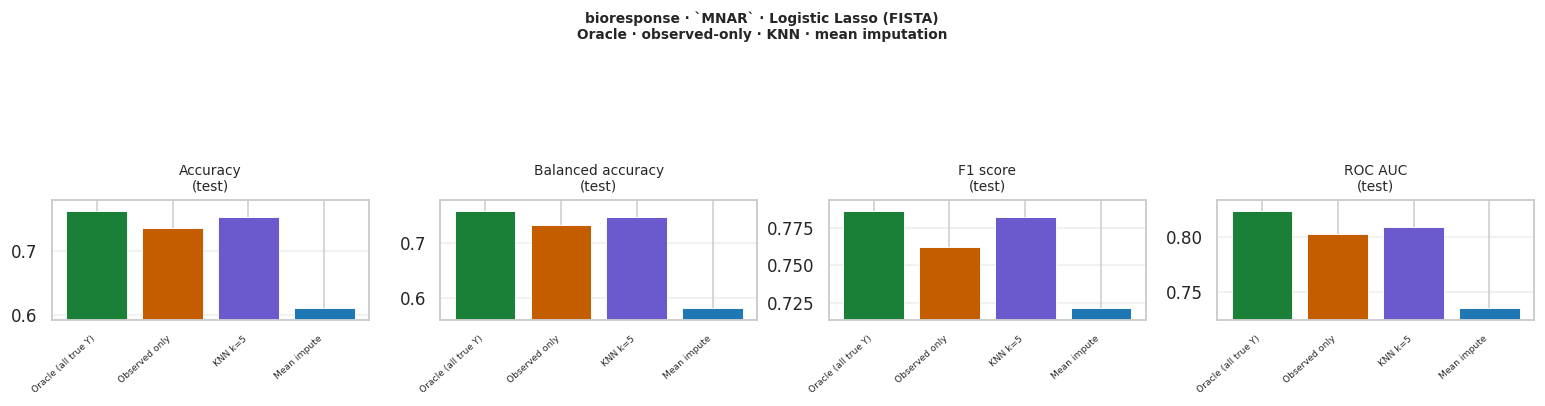

### gallstones


,accuracy,balanced_accuracy,f1,roc_auc
Strategy (then FISTA Lasso),,,,
Oracle — true Y on all training rows (reference),0.8438,0.8438,0.8387,0.8867
Observed only — FISTA on rows with known Y,0.8125,0.8125,0.8125,0.8838
"KNN imputation — missing Y from k=5 neighbor labels, FISTA on all rows",0.6875,0.6875,0.6774,0.8271
"Mean imputation — missing Y → majority class among observed, FISTA on all rows",0.7344,0.7344,0.7213,0.7881


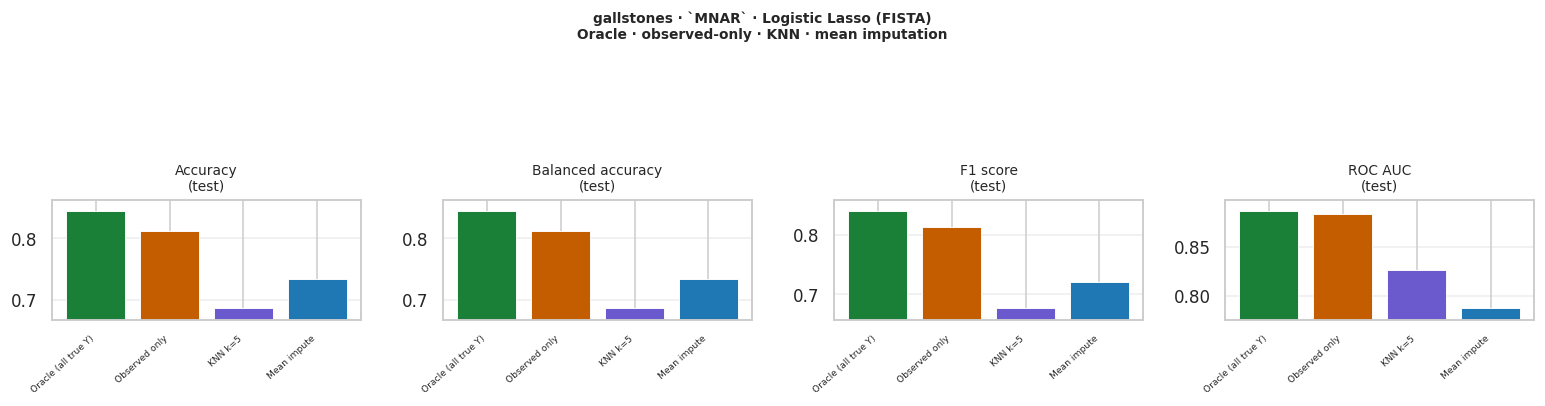

### musk


,accuracy,balanced_accuracy,f1,roc_auc
Strategy (then FISTA Lasso),,,,
Oracle — true Y on all training rows (reference),0.9356,0.8612,0.7826,0.9683
Observed only — FISTA on rows with known Y,0.9356,0.8612,0.7826,0.9666
"KNN imputation — missing Y from k=5 neighbor labels, FISTA on all rows",0.9356,0.8612,0.7826,0.9683
"Mean imputation — missing Y → majority class among observed, FISTA on all rows",0.9333,0.8538,0.7732,0.9653


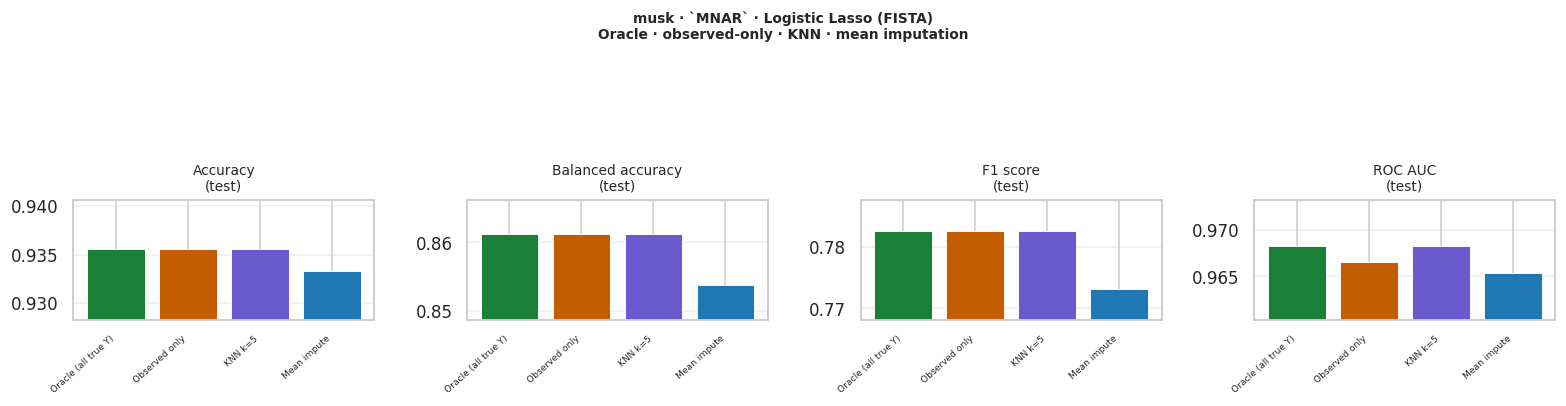

### spectrometer


,accuracy,balanced_accuracy,f1,roc_auc
Strategy (then FISTA Lasso),,,,
Oracle — true Y on all training rows (reference),0.9065,0.5455,0.1667,0.9953
Observed only — FISTA on rows with known Y,0.8972,0.5000,0.0000,0.9924
"KNN imputation — missing Y from k=5 neighbor labels, FISTA on all rows",0.8972,0.5000,0.0000,0.9981
"Mean imputation — missing Y → majority class among observed, FISTA on all rows",0.8972,0.5000,0.0000,0.9830


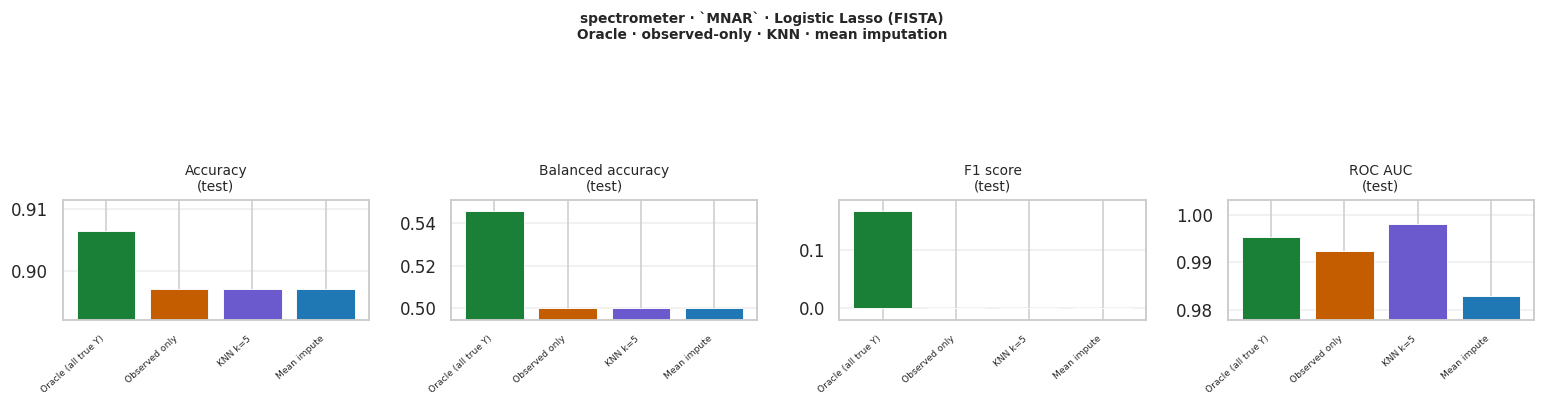

In [6]:
_show_results_for_scenario("MNAR")


## MAR

**Missing At Random**: missingness depends on **observed X** only. We use **MAR1** (one covariate drives missingness) and **MAR2** (several covariates). Under each heading, the same **per-dataset** FISTA Lasso comparison.


### MAR1

MAR with a **single** feature driving the missing-label mechanism.


### bioresponse


,accuracy,balanced_accuracy,f1,roc_auc
Strategy (then FISTA Lasso),,,,
Oracle — true Y on all training rows (reference),0.7617,0.7574,0.7861,0.8234
Observed only — FISTA on rows with known Y,0.7430,0.7402,0.7655,0.8181
"KNN imputation — missing Y from k=5 neighbor labels, FISTA on all rows",0.7497,0.7452,0.7757,0.8124
"Mean imputation — missing Y → majority class among observed, FISTA on all rows",0.7403,0.7269,0.7874,0.8022


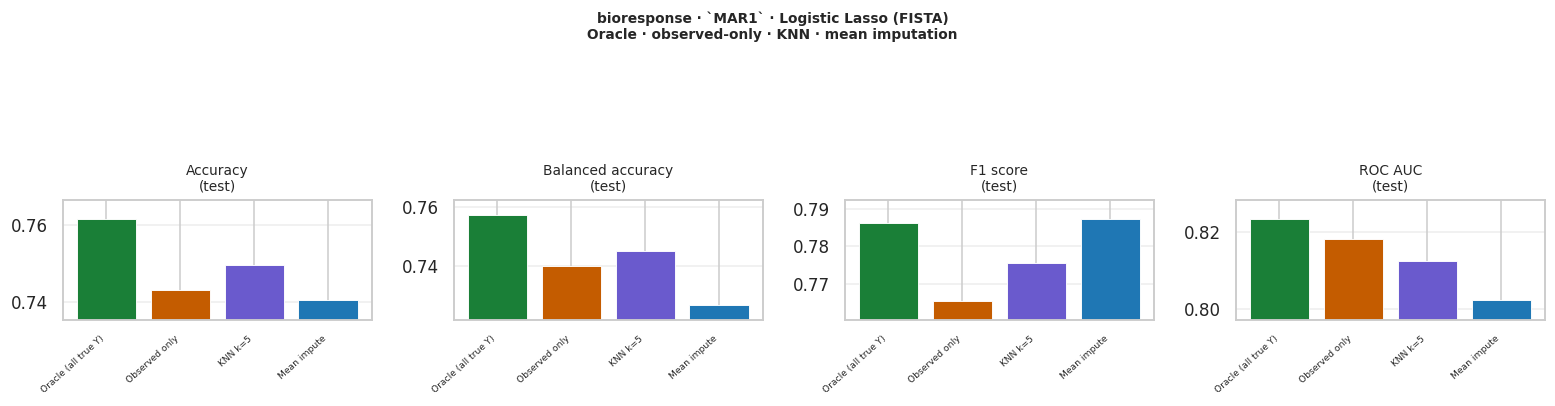

### gallstones


,accuracy,balanced_accuracy,f1,roc_auc
Strategy (then FISTA Lasso),,,,
Oracle — true Y on all training rows (reference),0.8438,0.8438,0.8387,0.8867
Observed only — FISTA on rows with known Y,0.7656,0.7656,0.7619,0.8770
"KNN imputation — missing Y from k=5 neighbor labels, FISTA on all rows",0.7500,0.7500,0.7333,0.8535
"Mean imputation — missing Y → majority class among observed, FISTA on all rows",0.7812,0.7812,0.8056,0.8379


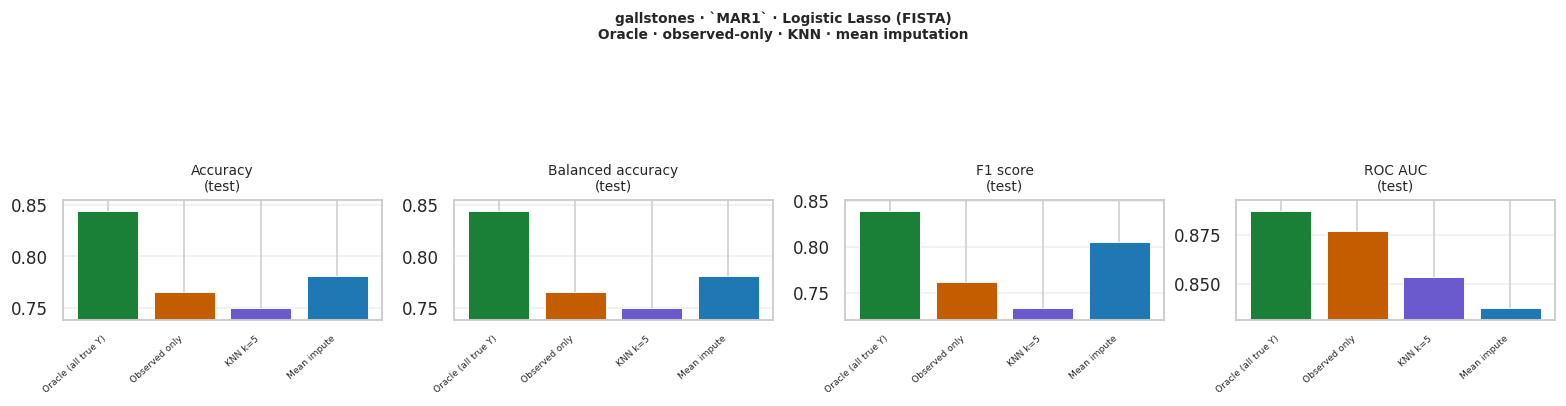

### musk


,accuracy,balanced_accuracy,f1,roc_auc
Strategy (then FISTA Lasso),,,,
Oracle — true Y on all training rows (reference),0.9356,0.8612,0.7826,0.9683
Observed only — FISTA on rows with known Y,0.9371,0.8641,0.7877,0.9629
"KNN imputation — missing Y from k=5 neighbor labels, FISTA on all rows",0.9348,0.8486,0.7737,0.9642
"Mean imputation — missing Y → majority class among observed, FISTA on all rows",0.9242,0.8081,0.7222,0.9588


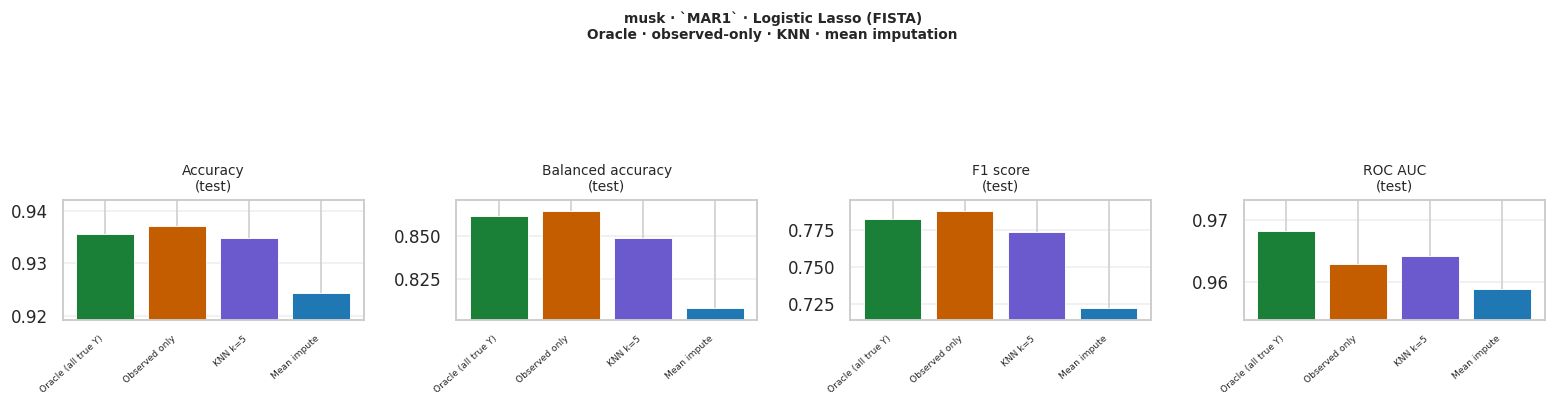

### spectrometer


,accuracy,balanced_accuracy,f1,roc_auc
Strategy (then FISTA Lasso),,,,
Oracle — true Y on all training rows (reference),0.9065,0.5455,0.1667,0.9953
Observed only — FISTA on rows with known Y,0.8972,0.5000,0.0000,1.0000
"KNN imputation — missing Y from k=5 neighbor labels, FISTA on all rows",0.8972,0.5000,0.0000,1.0000
"Mean imputation — missing Y → majority class among observed, FISTA on all rows",0.8972,0.5000,0.0000,0.9962


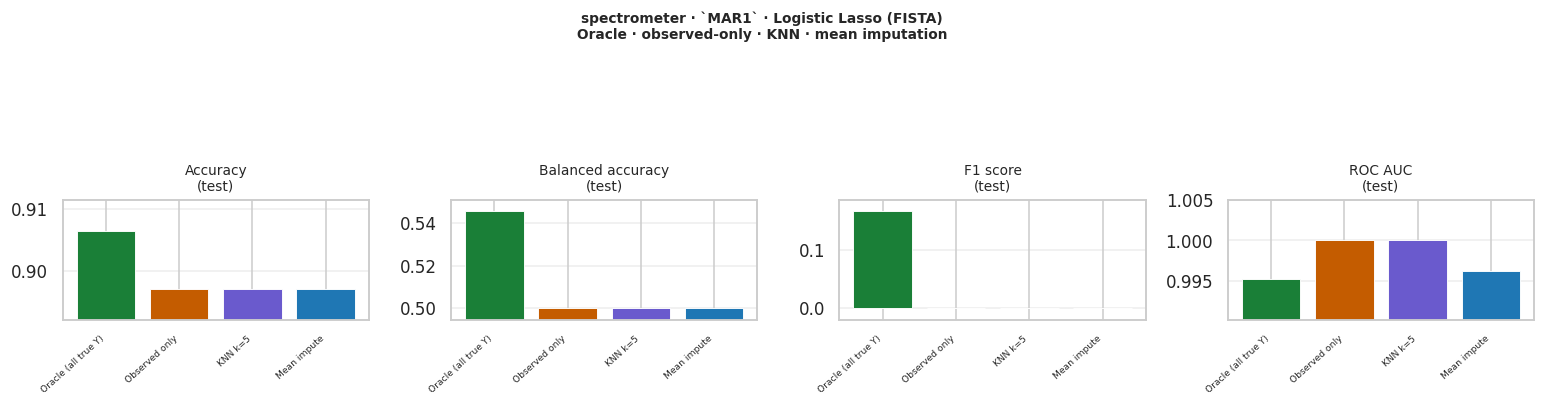

In [7]:
_show_results_for_scenario("MAR1")


### MAR2

MAR with **several** features driving the missing-label mechanism.


### bioresponse


,accuracy,balanced_accuracy,f1,roc_auc
Strategy (then FISTA Lasso),,,,
Oracle — true Y on all training rows (reference),0.7617,0.7574,0.7861,0.8234
Observed only — FISTA on rows with known Y,0.7364,0.7320,0.7632,0.8035
"KNN imputation — missing Y from k=5 neighbor labels, FISTA on all rows",0.7550,0.7494,0.7830,0.8090
"Mean imputation — missing Y → majority class among observed, FISTA on all rows",0.5446,0.5029,0.7042,0.7321


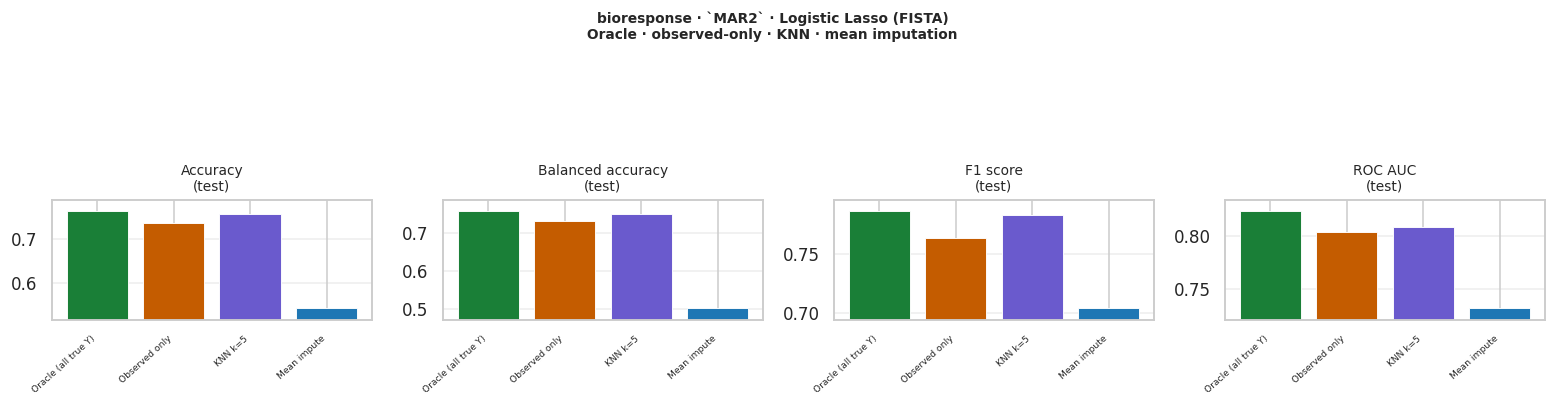

### gallstones


,accuracy,balanced_accuracy,f1,roc_auc
Strategy (then FISTA Lasso),,,,
Oracle — true Y on all training rows (reference),0.8438,0.8438,0.8387,0.8867
Observed only — FISTA on rows with known Y,0.8125,0.8125,0.8125,0.8613
"KNN imputation — missing Y from k=5 neighbor labels, FISTA on all rows",0.7031,0.7031,0.6780,0.8301
"Mean imputation — missing Y → majority class among observed, FISTA on all rows",0.7969,0.7969,0.8219,0.8779


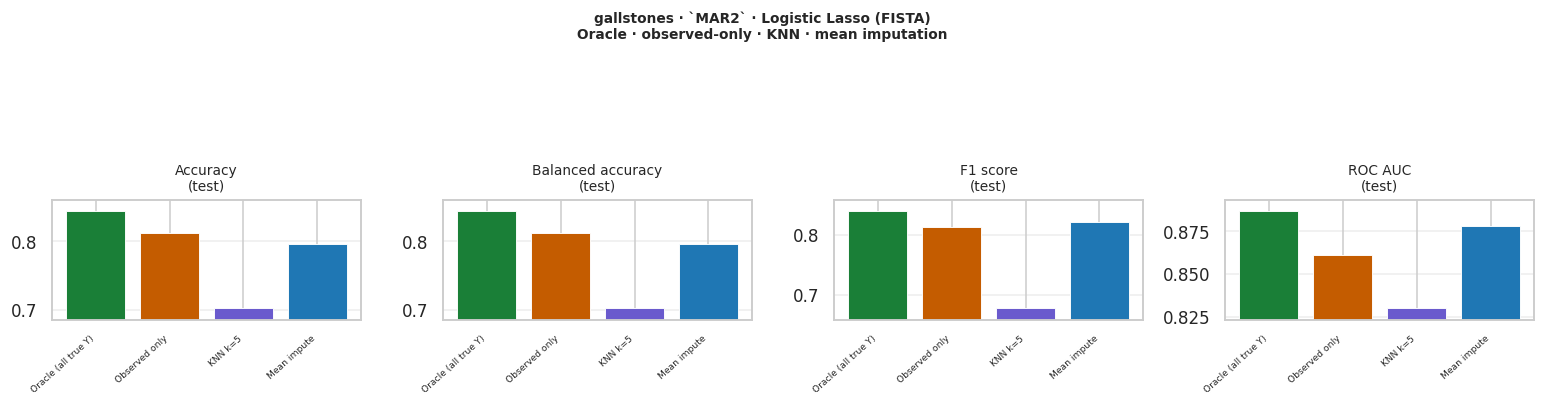

### musk


,accuracy,balanced_accuracy,f1,roc_auc
Strategy (then FISTA Lasso),,,,
Oracle — true Y on all training rows (reference),0.9356,0.8612,0.7826,0.9683
Observed only — FISTA on rows with known Y,0.9356,0.8612,0.7826,0.9666
"KNN imputation — missing Y from k=5 neighbor labels, FISTA on all rows",0.9356,0.8612,0.7826,0.9683
"Mean imputation — missing Y → majority class among observed, FISTA on all rows",0.9333,0.8538,0.7732,0.9653


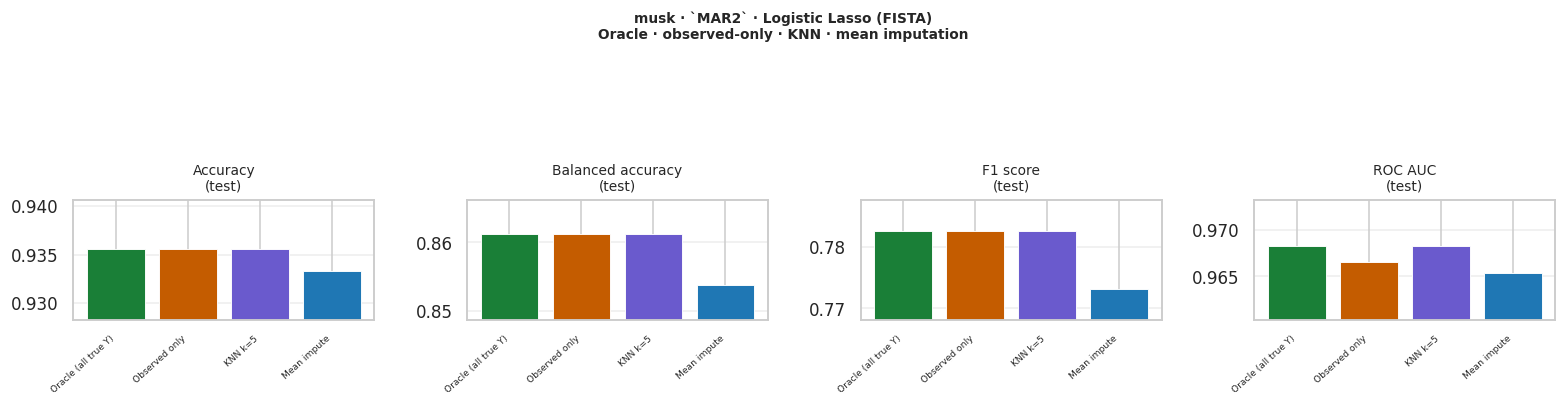

### spectrometer


,accuracy,balanced_accuracy,f1,roc_auc
Strategy (then FISTA Lasso),,,,
Oracle — true Y on all training rows (reference),0.9065,0.5455,0.1667,0.9953
Observed only — FISTA on rows with known Y,0.8972,0.5000,0.0000,0.9924
"KNN imputation — missing Y from k=5 neighbor labels, FISTA on all rows",0.8972,0.5000,0.0000,0.9981
"Mean imputation — missing Y → majority class among observed, FISTA on all rows",0.8972,0.5000,0.0000,0.9830


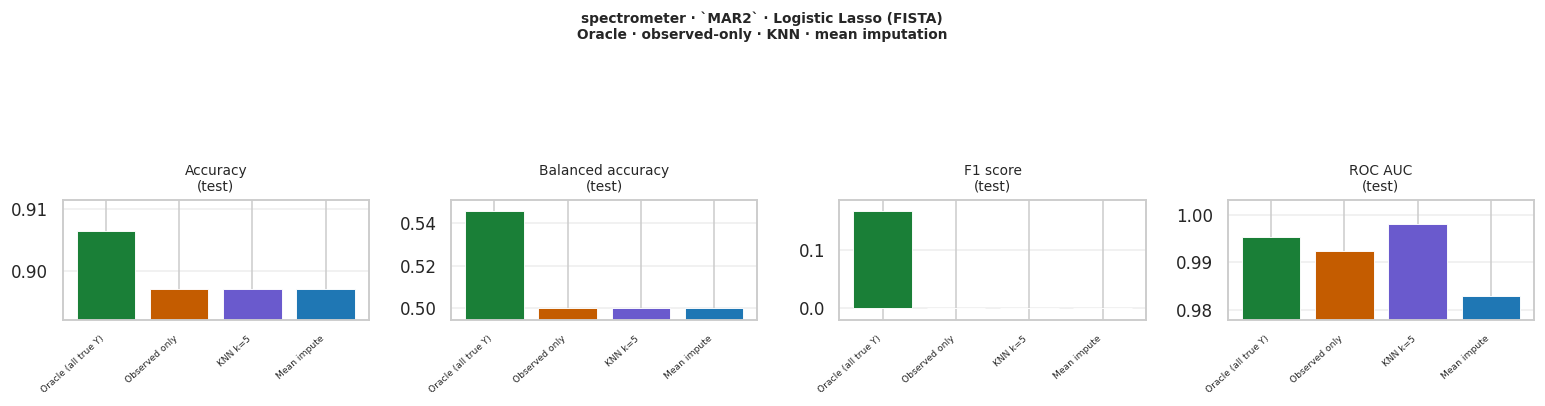

In [8]:
_show_results_for_scenario("MAR2")


## MCAR

**Missing Completely At Random**: whether a training–fit label is missing does **not** depend on **X** or **Y**. In the main grid, the removal probability is **`MISSING_FRAC`** (often denoted **c**). Same **per-dataset** comparison: Oracle, observed-only, KNN, mean imputation — all **`LogisticLassoFISTA`**.


### bioresponse


,accuracy,balanced_accuracy,f1,roc_auc
Strategy (then FISTA Lasso),,,,
Oracle — true Y on all training rows (reference),0.7617,0.7574,0.7861,0.8234
Observed only — FISTA on rows with known Y,0.7483,0.7449,0.7720,0.8191
"KNN imputation — missing Y from k=5 neighbor labels, FISTA on all rows",0.7603,0.7555,0.7862,0.8160
"Mean imputation — missing Y → majority class among observed, FISTA on all rows",0.7364,0.7230,0.7838,0.8124


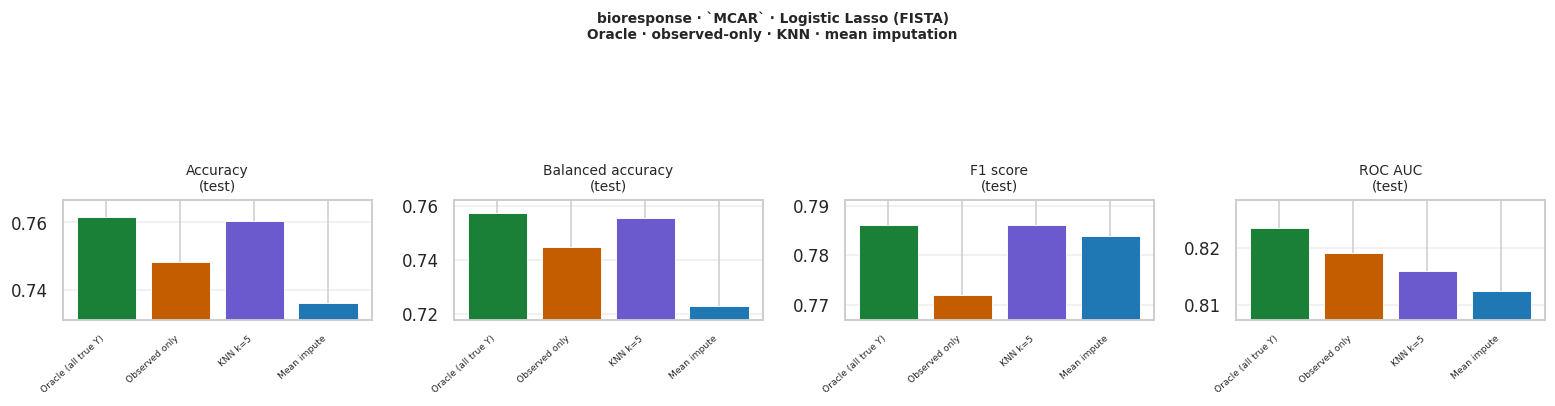

### gallstones


,accuracy,balanced_accuracy,f1,roc_auc
Strategy (then FISTA Lasso),,,,
Oracle — true Y on all training rows (reference),0.8438,0.8438,0.8387,0.8867
Observed only — FISTA on rows with known Y,0.8125,0.8125,0.8125,0.8828
"KNN imputation — missing Y from k=5 neighbor labels, FISTA on all rows",0.8438,0.8438,0.8333,0.9082
"Mean imputation — missing Y → majority class among observed, FISTA on all rows",0.7188,0.7188,0.7500,0.8672


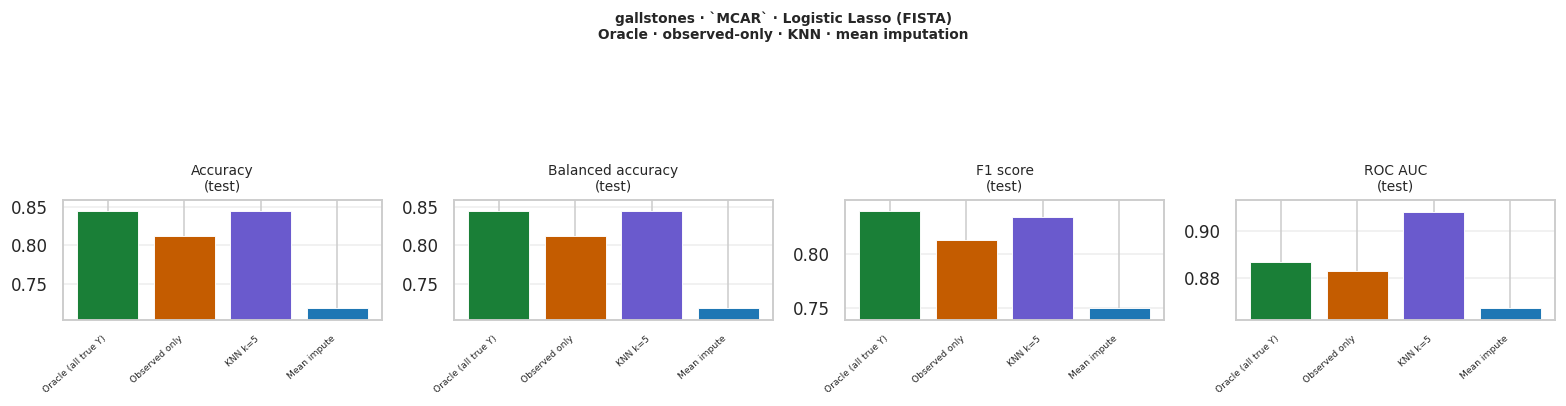

### musk


,accuracy,balanced_accuracy,f1,roc_auc
Strategy (then FISTA Lasso),,,,
Oracle — true Y on all training rows (reference),0.9356,0.8612,0.7826,0.9683
Observed only — FISTA on rows with known Y,0.9364,0.8657,0.7868,0.9640
"KNN imputation — missing Y from k=5 neighbor labels, FISTA on all rows",0.9348,0.8486,0.7737,0.9649
"Mean imputation — missing Y → majority class among observed, FISTA on all rows",0.9182,0.7864,0.6914,0.9586


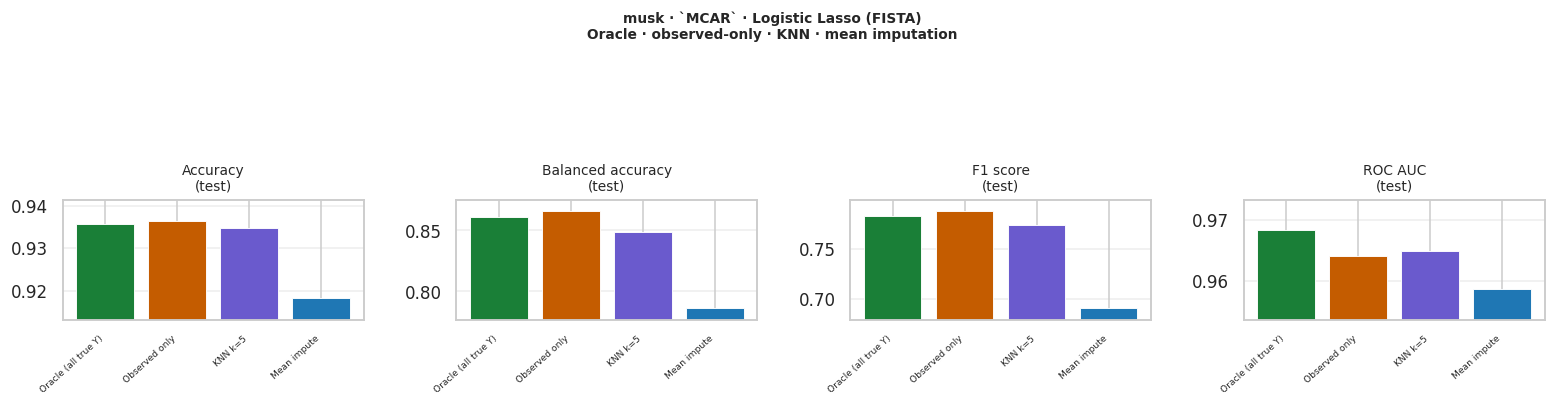

### spectrometer


,accuracy,balanced_accuracy,f1,roc_auc
Strategy (then FISTA Lasso),,,,
Oracle — true Y on all training rows (reference),0.9065,0.5455,0.1667,0.9953
Observed only — FISTA on rows with known Y,0.9065,0.5455,0.1667,0.9962
"KNN imputation — missing Y from k=5 neighbor labels, FISTA on all rows",0.8972,0.5000,0.0000,0.9962
"Mean imputation — missing Y → majority class among observed, FISTA on all rows",0.9252,0.6364,0.4286,0.9972


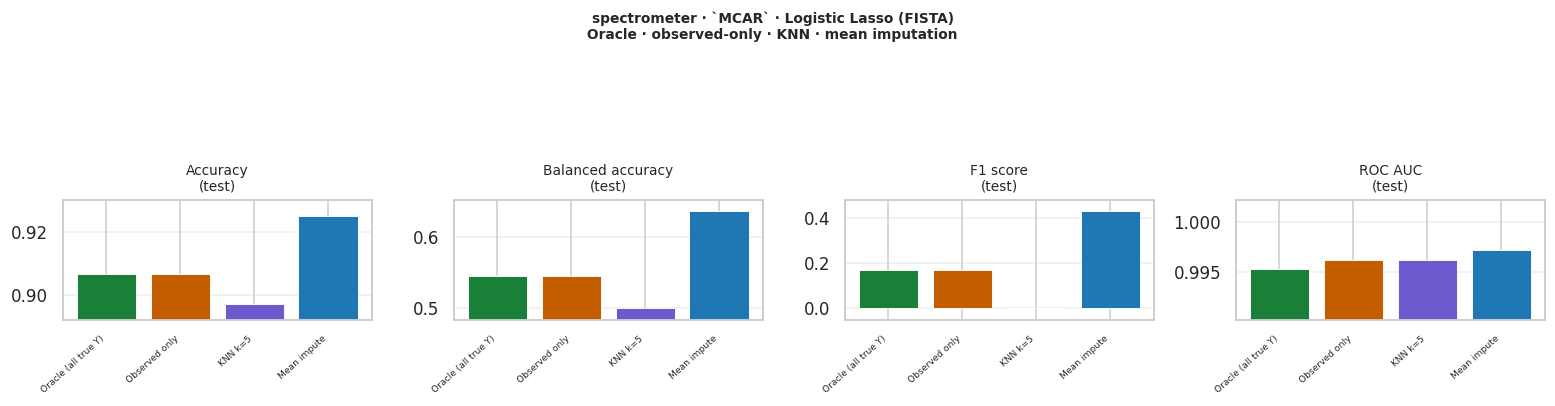

In [9]:
_show_results_for_scenario("MCAR")


### Stratified test metrics (MAR / MNAR)

For **MAR1**, **MAR2**, and **MNAR**, each test row gets a **simulated** observed/unobserved flag from the **same** missingness mechanism as training (new Bernoulli draws on the test fold). Tables below split metrics into **`sim_obs`** (mask says label would be observed) vs **`sim_unobs`** (would be missing). True **Y** is used only for **evaluation**.


In [10]:
for _sk in ["MAR1", "MAR2", "MNAR"]:
    _show_stratified_mar_mnar(_sk)


Stratified **MAR1** — same missingness DGP as training, independent Bernoulli draws on the **test** fold; `sim_unobs` = mask True.

#### `bioresponse`

**Accuracy**

eval_stratum,sim_obs,sim_unobs
Oracle — true Y on all training rows (reference),0.7529,0.7949
Observed only — FISTA on rows with known Y,0.7345,0.7756
"KNN imputation — missing Y from k=5 neighbor labels, FISTA on all rows",0.7412,0.7821
"Mean imputation — missing Y → majority class among observed, FISTA on all rows",0.7361,0.7564


**Balanced accuracy**

...

eval_stratum,sim_obs
Oracle — true Y on all training rows (reference),0.5455
Observed only — FISTA on rows with known Y,0.5000
"KNN imputation — missing Y from k=5 neighbor labels, FISTA on all rows",0.5000
"Mean imputation — missing Y → majority class among observed, FISTA on all rows",0.5000


**F1 score**

eval_stratum,sim_obs
Oracle — true Y on all training rows (reference),0.1667
Observed only — FISTA on rows with known Y,0.0000
"KNN imputation — missing Y from k=5 neighbor labels, FISTA on all rows",0.0000
"Mean imputation — missing Y → majority class among observed, FISTA on all rows",0.0000


**ROC AUC**

eval_stratum,sim_obs
Oracle — true Y on all training rows (reference),0.9939
Observed only — FISTA on rows with known Y,0.9903
"KNN imputation — missing Y from k=5 neighbor labels, FISTA on all rows",0.9976
"Mean imputation — missing Y → majority class among observed, FISTA on all rows",0.9782


### MCAR sensitivity analysis — parameter **c**

The plots below vary **c** only under **MCAR**:

- **c** = probability that a **training–fit** label is hidden (missing). It is **not** used for MAR1, MAR2, or MNAR in this sweep.
- The **x-axis** is **c**; each line is one **training strategy** (Oracle, observed-only, KNN, or mean imputation).
- **Dataset** is stated in each figure’s main title.

Use this to discuss how badly performance degrades as **more** labels go missing under MCAR.


In [11]:
C_GRID = np.linspace(0.1, 0.5, 5)


def run_mcar_sweep(csv_name: str, c: float, seed: int) -> list[dict]:
    path = os.path.join(DATA_DIR, csv_name)
    df_raw = pd.read_csv(path)
    X = df_raw.drop(columns=["class"]).values.astype(float)
    y = df_raw["class"].values.astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=seed, stratify=y
    )
    X_sub, X_val, y_sub, y_val = train_test_split(
        X_train, y_train, test_size=VAL_FRAC, random_state=seed + 1, stratify=y_train
    )
    rng = np.random.default_rng(seed + 2)
    df_std, X_val_s, X_test_s = _standardize_fit_val_test(X_sub, y_sub, X_val, X_test)
    y_val = y_val.astype(int)
    y_test = y_test.astype(int)

    df_miss, _ = apply_missingness(df_std, "MCAR", rng, target_fraction=float(c))

    X_fit = df_miss.drop(columns=["class_observed"]).values.astype(float)
    y_obs = df_miss["class_observed"].values.astype(int)
    y_true_fit = y_sub.astype(int)

    scores = fit_oracle_naive_unlabeled(
        X_fit, y_true_fit, y_obs, X_val_s, y_val, X_test_s, y_test, "MCAR", None
    )
    rows = []
    for method, strata in scores.items():
        for eval_stratum, met_dict in strata.items():
            row = {
                "dataset": csv_name.replace(".csv", ""),
                "c": c,
                "method": method,
                "seed": seed,
                "eval_stratum": eval_stratum,
            }
            row.update(met_dict)
            rows.append(row)
    return rows


sweep_rows: list[dict] = []
for csv_name in DATASETS:
    for c in C_GRID:
        sweep_rows.extend(run_mcar_sweep(csv_name, float(c), RANDOM_STATE))

mcar_sweep = pd.DataFrame(sweep_rows)

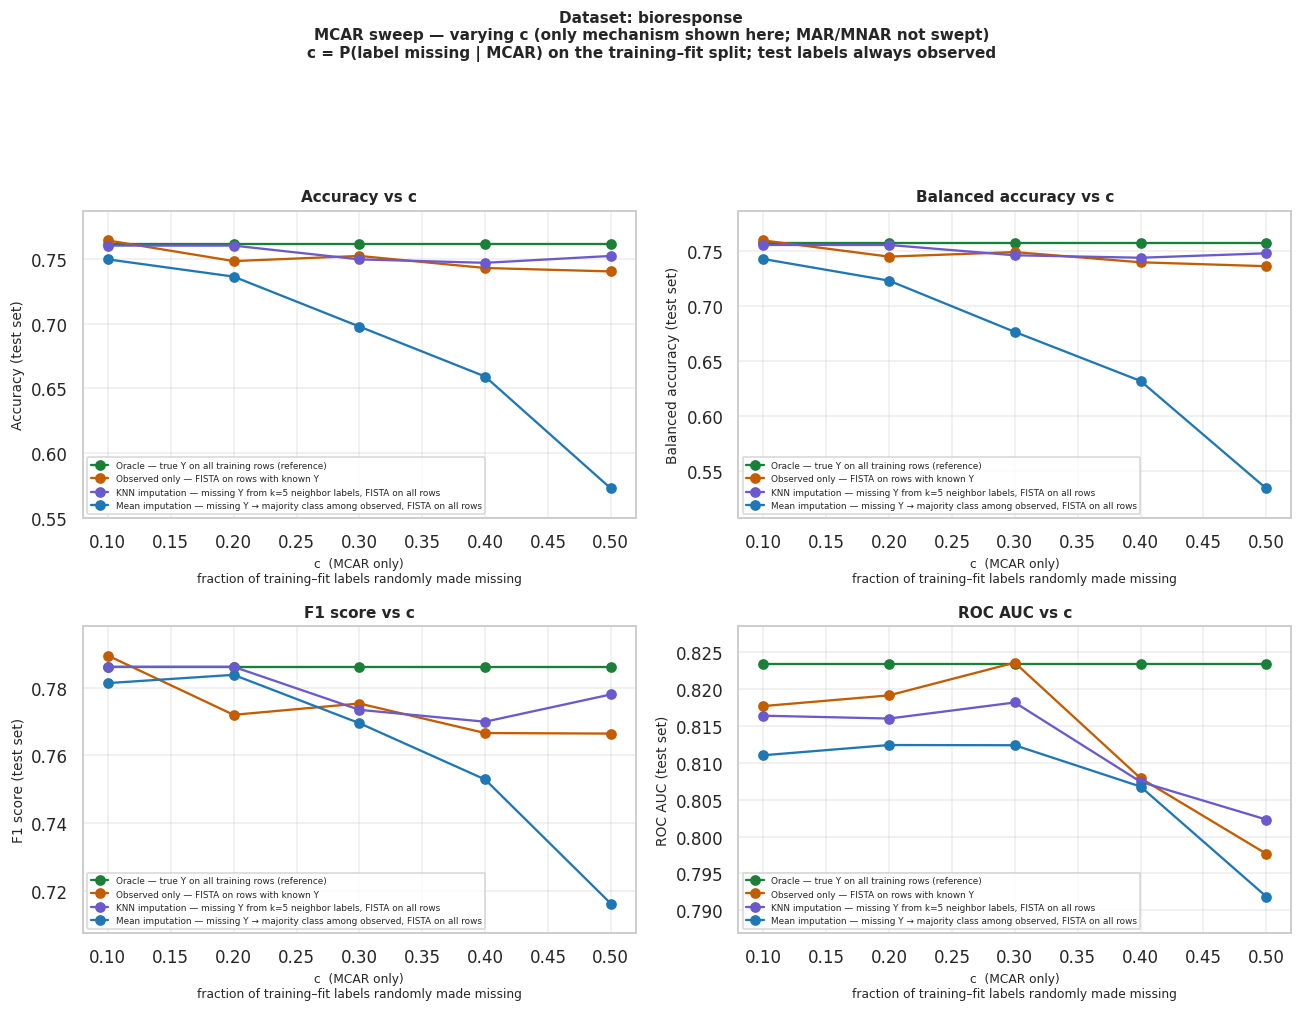

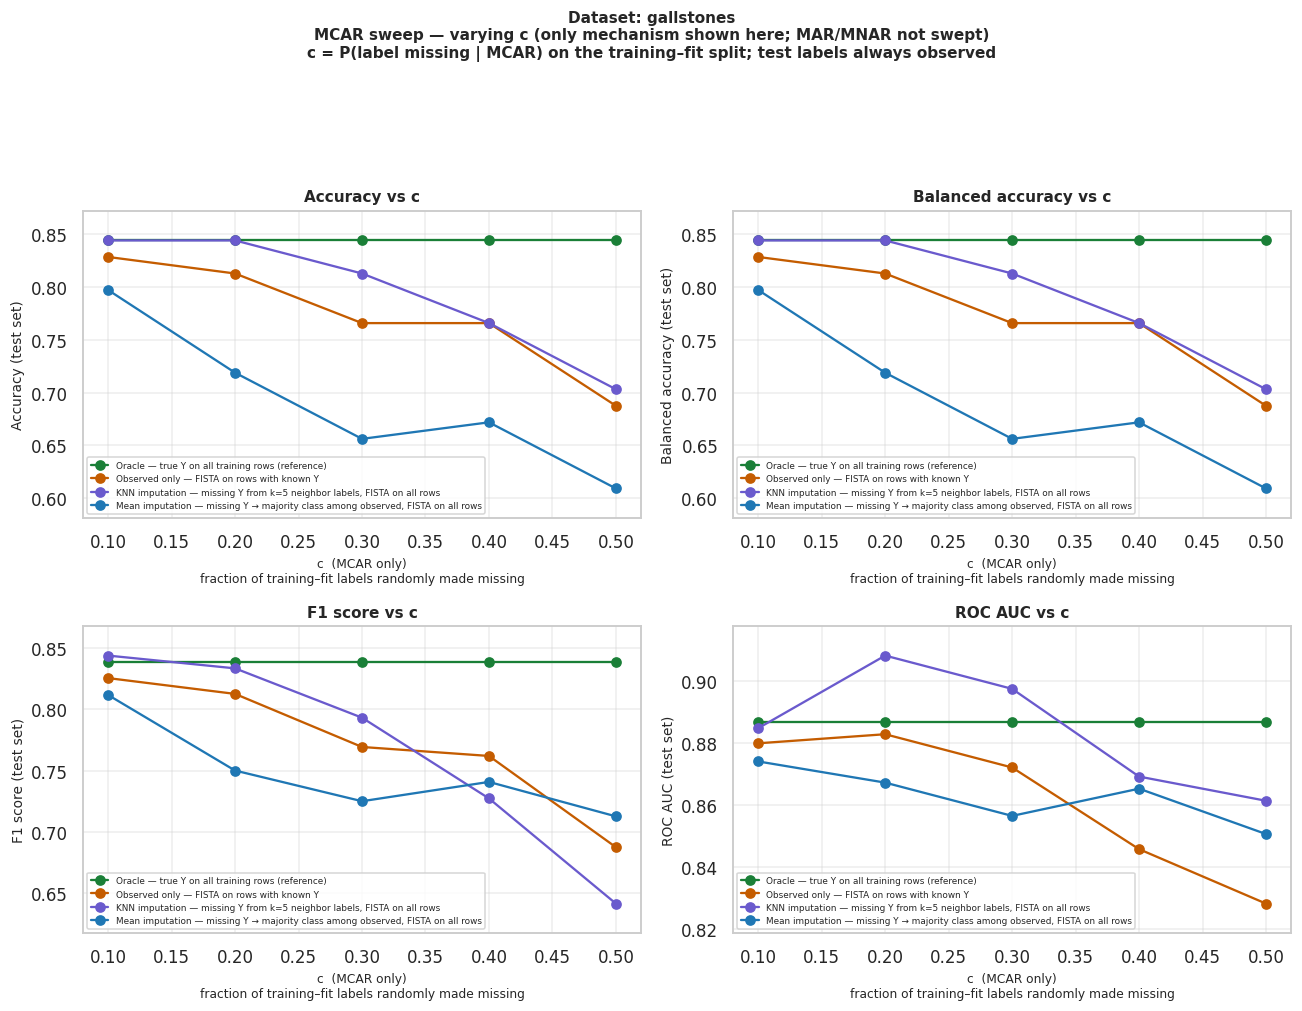

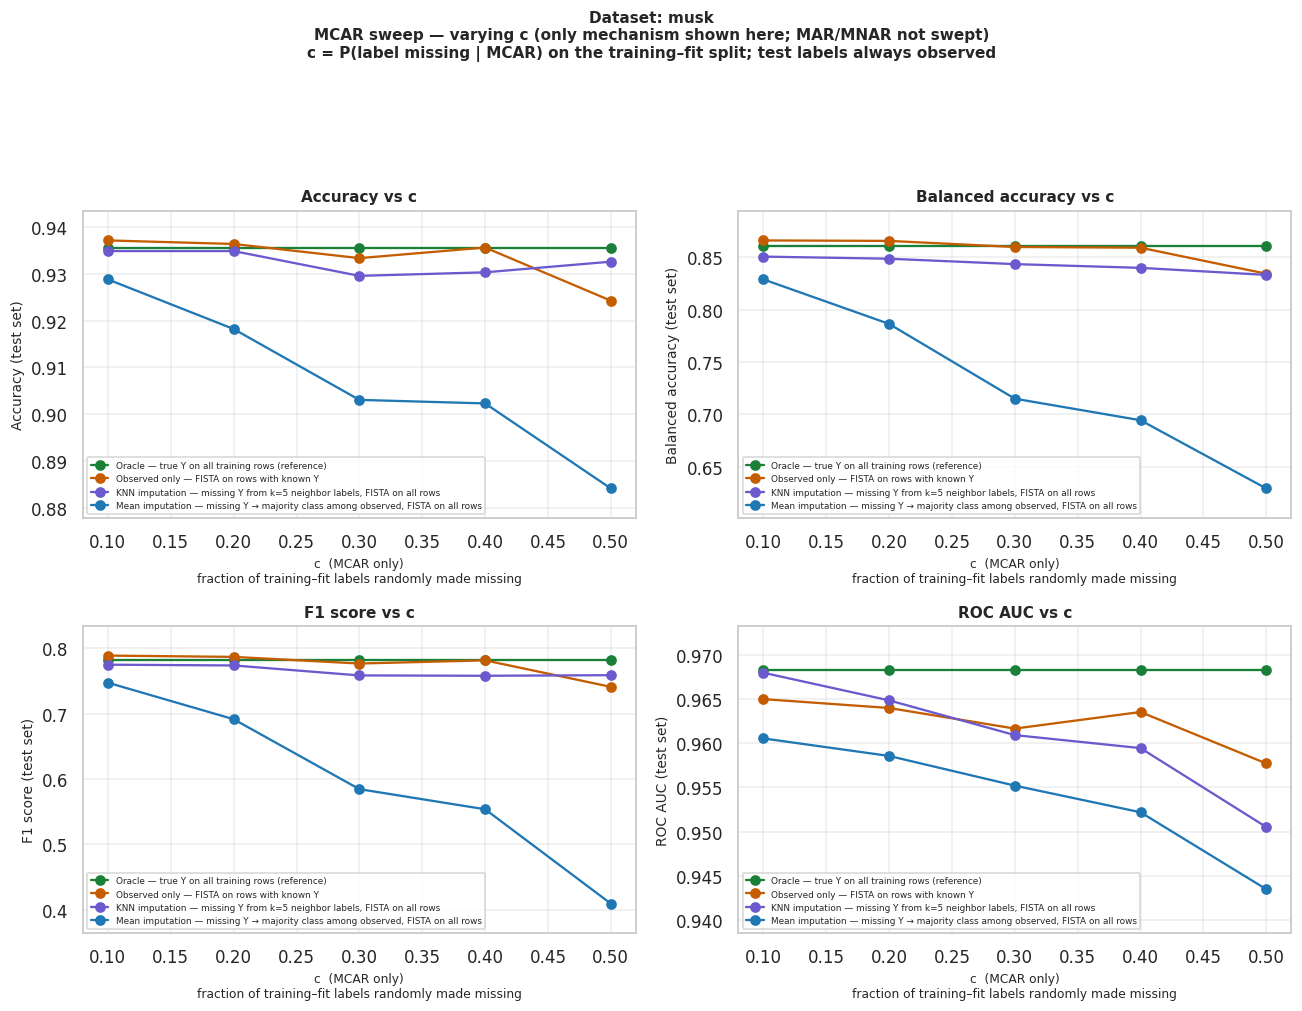

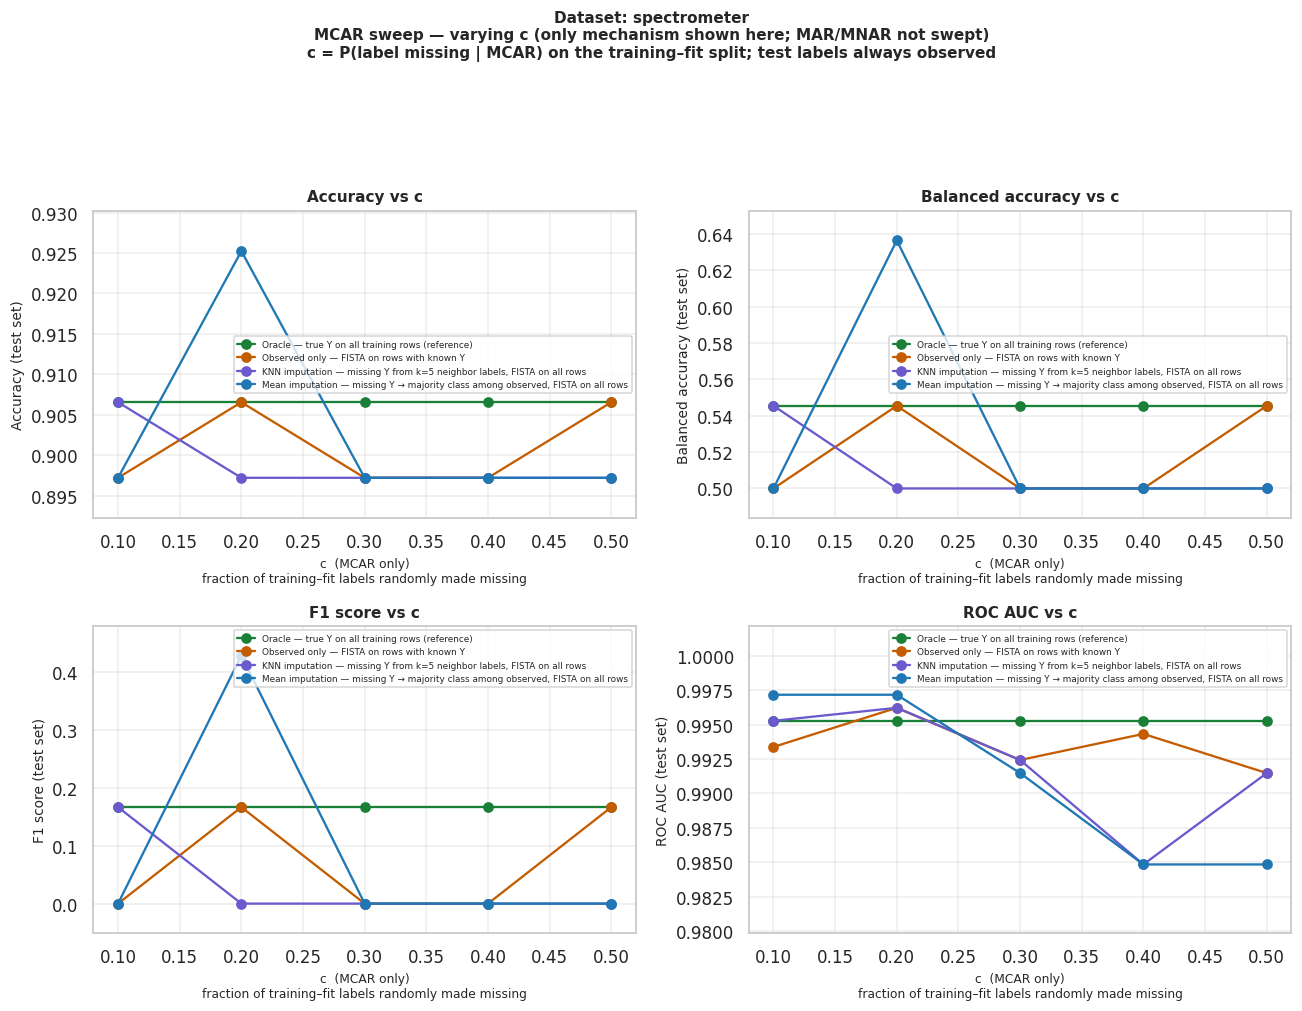

In [12]:
def plot_mcar_sweep_dataset(df_ds: pd.DataFrame, dataset_name: str) -> None:
    df_ds = df_ds[df_ds["eval_stratum"] == "all"]
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    L1, L2, L3 = _analysis_banner_lines(dataset_name)
    for ax, metric in zip(axes.ravel(), METRICS):
        ys: list[float] = []
        for method in METHOD_ORDER:
            sub = df_ds[df_ds["method"] == method].sort_values("c")
            v = sub[metric].to_numpy(dtype=float)
            ys.extend(v[np.isfinite(v)].tolist())
        for method in METHOD_ORDER:
            sub = df_ds[df_ds["method"] == method].sort_values("c")
            ax.plot(
                sub["c"],
                sub[metric],
                marker="o",
                label=METHOD_LEGEND_LABELS[method],
                color=METHOD_COLORS[method],
            )
        tit = METRIC_TITLES.get(metric, metric)
        ax.set_xlabel(
            "c  (MCAR only)\n"
            "fraction of training–fit labels randomly made missing",
            fontsize=8,
        )
        ax.set_ylabel(f"{tit} (test set)", fontsize=9)
        ax.set_title(f"{tit} vs c", fontweight="bold", fontsize=10)
        if ys:
            lo, hi = min(ys), max(ys)
            span = hi - lo
            pad = max(span * 0.12, 0.005) if span > 0 else 0.02
            y0, y1 = lo - pad, min(1.05, hi + pad)
            if y1 <= y0:
                y1 = y0 + 0.05
            ax.set_ylim(y0, y1)
        else:
            ax.set_ylim(0, 1.05)
        ax.grid(alpha=0.35)
        ax.legend(fontsize=5.8, loc="best")
    fig.suptitle(
        f"{L1}\n"
        "MCAR sweep — varying c (only mechanism shown here; MAR/MNAR not swept)\n"
        "c = P(label missing | MCAR) on the training–fit split; test labels always observed",
        fontsize=10,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


for ds in mcar_sweep["dataset"].unique():
    plot_mcar_sweep_dataset(mcar_sweep[mcar_sweep["dataset"] == ds], ds)


### Optional — wide pivot tables

Same metrics as above in **pivot** form (rows = training strategy, columns = **MCAR / MAR1 / MAR2 / MNAR**). Use if you prefer a single table per metric for the report.


In [13]:
for ds in results["dataset"].unique():
    sub = results[(results["dataset"] == ds) & (results["eval_stratum"] == "all")]
    print(f"\n=== {ds} (pivot: rows = method key) ===")
    for metric in METRICS:
        p = sub.pivot_table(index="method", columns="scenario", values=metric, aggfunc="mean")
        p = p.reindex(index=[m for m in METHOD_ORDER if m in p.index], columns=SCENARIO_KEYS)
        p.index = [METHOD_LEGEND_LABELS.get(i, i) for i in p.index]
        print(f"\n{METRIC_TITLES.get(metric, metric)}:")
        print(p.round(4).to_string())



=== bioresponse (pivot: rows = method key) ===

Accuracy:
scenario                                                                          MCAR    MAR1    MAR2    MNAR
Oracle — true Y on all training rows (reference)                                0.7617  0.7617  0.7617  0.7617
Observed only — FISTA on rows with known Y                                      0.7483  0.7430  0.7364  0.7364
KNN imputation — missing Y from k=5 neighbor labels, FISTA on all rows          0.7603  0.7497  0.7550  0.7537
Mean imputation — missing Y → majority class among observed, FISTA on all rows  0.7364  0.7403  0.5446  0.6112

Balanced accuracy:
scenario                                                                          MCAR    MAR1    MAR2    MNAR
Oracle — true Y on all training rows (reference)                                0.7574  0.7574  0.7574  0.7574
Observed only — FISTA on rows with known Y                                      0.7449  0.7402  0.7320  0.7322
KNN imputation — missing Y from k